## How Chagas Probability and Decision Threshold Are Computed

### Chagas Probability
The model outputs a raw **logit** — an unbounded real number from the final MLP classifier.  
To convert to a probability:

```
P(Chagas) = sigmoid(logit) = 1 / (1 + exp(-logit))
```

A value of `0.9` means the model assigns 90% probability that the ECG shows Chagas disease patterns.  
A value of `0.1` means 10%. The ranking of scores is what drives the primary metric (TPR@5%), not the absolute values.

### Decision Threshold (Youden's J — recall-based)
The challenge score (TPR@5%) is **threshold-free** — it ranks all patients by score and measures how many
true Chagas cases fall in the top 5% of predictions. No binary cut-off is needed for the primary metric.

For binary decisions (positive/negative), the threshold is computed using **recall (TPR)** via Youden's J:

```
For each candidate threshold T from the ROC curve:
    J(T) = TPR(T) - FPR(T)  =  Recall(T) - (1 - Specificity(T))

T* = argmax_T J(T)
```

This selects the threshold that maximises recall while controlling false positives — the standard
recall-based threshold for medical screening with class imbalance (~2% Chagas positive).

If the supervisor specifies a minimum recall requirement (e.g. "must catch >= 90% of cases"):
change `THRESHOLD_STRATEGY = 'min_recall'` and set `THRESHOLD_KWARGS = {'min_recall': 0.90}`.

### Evaluation Metrics
All of the following are computed during validation and testing — none of them select the threshold:
- **AUROC** — primary, threshold-free ranking metric (best checkpoint criterion)
- **AUPRC** — secondary, threshold-free
- **F1** — harmonic mean of precision and recall, computed at the Youden threshold
- **Precision, Recall, Accuracy** — at the Youden threshold
- **TPR@5%** — PhysioNet challenge score (reference only, not the thesis primary metric)

A sensitivity analysis table at recall targets [70%, 75%, 80%, 85%, 90%, 95%] is generated
so the supervisor can choose an alternative operating point if required.

### Early Stopping
Phase 2 trains for up to `PHASE2_MAX_EPOCHS` epochs. After each epoch, if val AUROC does not improve
by at least `EARLY_STOPPING_MIN_DELTA` for `EARLY_STOPPING_PATIENCE` consecutive epochs, training stops.
The best checkpoint (highest val AUROC) is saved automatically.

## Cell 1 — Imports

In [1]:
import os, sys
from pathlib import Path

# Set before any CUDA op — lets the allocator grow segments instead of
# failing on fragmented gaps. Required for 6 GB GPU with 173M-param model.
os.environ.setdefault('PYTORCH_CUDA_ALLOC_CONF', 'expandable_segments:True')

project_root = Path.cwd().parent
if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

import torch
import numpy as np
import pandas as pd
from torch.utils.tensorboard import SummaryWriter

from src.models.hybrid_model import HybridChagasModel
from src.training.dataset import create_dataloaders_final_split
from src.training.trainer import ChagasTrainer

torch.manual_seed(42)
np.random.seed(42)

device = 'cuda' if torch.cuda.is_available() else 'cpu'
if device != 'cuda':
    raise RuntimeError('GPU required — switch runtime to GPU')

gpu_name = torch.cuda.get_device_name(0)
gpu_gb   = torch.cuda.get_device_properties(0).total_memory / 1e9
print(f'GPU: {gpu_name}  ({gpu_gb:.1f} GB)')
if gpu_gb < 5.5:
    raise RuntimeError(f'Need >=6 GB GPU, found {gpu_gb:.1f} GB')
print(f'ALLOC_CONF: {os.environ.get("PYTORCH_CUDA_ALLOC_CONF", "(not set)")}')

✓ Official PhysioNet helper_code loaded from:
  D:\IIT\L6\FYP\ChagaSight\external\official_2025\helper_code.py
GPU: NVIDIA GeForce RTX 3050 6GB Laptop GPU  (6.4 GB)
ALLOC_CONF: expandable_segments:True


## Cell 2 — Configuration

In [2]:
# ── QUICK TEST ──────────────────────────────────────────────────────────────
QUICK_TEST    = False
FRACTION_DATA = 1.0
USE_PRETRAINED = False

# ── PATHS ───────────────────────────────────────────────────────────────────
DATA_DIR       = project_root / 'data' / 'processed'
METADATA_CSV   = DATA_DIR / 'metadata' / 'final_split.csv'
IMAGES_DIR     = DATA_DIR / '2d_images'
SIGNALS_DIR    = DATA_DIR / '1d_signals_100hz'
CHECKPOINT_DIR = project_root / 'checkpoints_new'
CHECKPOINT_DIR.mkdir(parents=True, exist_ok=True)
MAE_CHECKPOINT   = CHECKPOINT_DIR / 'mae_2d_pretrained.pt'
STMEM_CHECKPOINT = CHECKPOINT_DIR / 'stmem_1d_pretrained.pt'

assert METADATA_CSV.exists(), f'Missing metadata: {METADATA_CSV}'
if USE_PRETRAINED:
    if not MAE_CHECKPOINT.exists():
        print(f'WARNING: MAE pretrained weights not found: {MAE_CHECKPOINT}')
        print('  2D-ViT will train from random initialisation.')
        USE_PRETRAINED = False
    if not STMEM_CHECKPOINT.exists():
        print(f'WARNING: ST-MEM pretrained weights not found: {STMEM_CHECKPOINT}')
        print('  1D-ViT FM will train from random initialisation.')
        USE_PRETRAINED = False

# ── HARDWARE ────────────────────────────────────────────────────────────────
# 173M-param model on 6 GB GPU:
#   Phase 1 (FM frozen, ~1M active params): batch=8, accum=8 → eff.batch=64
#   Phase 2 (FM unfrozen, 173M params):     batch=8, accum=4 → eff.batch=32
# Effective batch sizes match the original design; only per-step tensors shrink.
BATCH_SIZE        = 8
PHASE1_GRAD_ACCUM = 8    # keeps Phase 1 eff.batch=64 (same as before)
PHASE2_GRAD_ACCUM = 4    # keeps Phase 2 eff.batch=32 (same as before)
NUM_WORKERS       = 2
USE_AMP           = True
MAX_GRAD_NORM     = 1.0

# ── PHASE 1 ─────────────────────────────────────────────────────────────────
PHASE1_ITERATIONS = 2000
WARMUP_ITERS      = 200
PHASE1_LR         = 2e-4

# ── PHASE 2 ─────────────────────────────────────────────────────────────────
PHASE2_MAX_EPOCHS        = 50
EARLY_STOPPING_PATIENCE  = 10
EARLY_STOPPING_MIN_DELTA = 1e-4
PHASE2_LR_HIGH           = 2e-4
PHASE2_LR_LOW            = 2e-5

# ── LOSS WEIGHTS ─────────────────────────────────────────────────────────────
POS_WEIGHT       = 10.0
GAMMA_NEG        = 2.0
ALIGNMENT_WEIGHT = 0.5

# ── THRESHOLD STRATEGY ───────────────────────────────────────────────────────
# Youden's J: T* = argmax(TPR - FPR) = argmax(Recall - (1 - Specificity))
# Named strategies (rec, recp, f1, t05) are always computed in Dewmika format.
THRESHOLD_STRATEGY = 'youden'
THRESHOLD_KWARGS   = {}

# ── AUGMENTATION ────────────────────────────────────────────────────────────
PAPER_AUGMENTATION_CONFIG = {
    'lead_mixup':        {'prob': 0.3, 'alpha': 0.2},
    'powerline_noise':   {'prob': 0.5, 'use_snr': True, 'snr_range': (15, 30),
                          'random_freq': True, 'add_harmonics': True},
    'random_shift':      {'prob': 0.5, 'max_shift': 100},
    'amplitude_scaling': {'prob': 0.3, 'scale_range': (0.8, 1.2)},
    'baseline_wander':   {'prob': 0.2, 'amplitude': 0.2, 'freq_range': (0.1, 0.5)},
}

# ── QUICK TEST OVERRIDES ─────────────────────────────────────────────────────
if QUICK_TEST:
    FRACTION_DATA           = 0.01
    PHASE1_ITERATIONS       = 25
    PHASE2_MAX_EPOCHS       = 2
    WARMUP_ITERS            = 10
    EARLY_STOPPING_PATIENCE = 2
    NUM_WORKERS             = 0

# ── RUN DIRECTORY — separate subfolder per run type ──────────────────────────
if QUICK_TEST:
    _run_tag = f'quick_p1_{PHASE1_ITERATIONS}iters_p2_{PHASE2_MAX_EPOCHS}epochs'
else:
    _run_tag = f'full_p2_{PHASE2_MAX_EPOCHS}epochs'

RUN_DIR     = CHECKPOINT_DIR / _run_tag
PLOTS_DIR   = RUN_DIR / 'plots'
RESULTS_DIR = RUN_DIR / 'results'
TB_LOG_DIR  = RUN_DIR / 'tb_logs'
for _d in [RUN_DIR, PLOTS_DIR, RESULTS_DIR, TB_LOG_DIR]:
    _d.mkdir(parents=True, exist_ok=True)

# ── AUTO-RESUME ──────────────────────────────────────────────────────────────
_ckpt = RUN_DIR / 'foldfinal_latest.pt'
RESUME_FROM = str(_ckpt) if _ckpt.exists() else None

print(f'QUICK_TEST={QUICK_TEST}  |  FRACTION_DATA={FRACTION_DATA}  |  USE_PRETRAINED={USE_PRETRAINED}')
print(f'Run folder: {RUN_DIR.name}')
print(f'  Plots:        {PLOTS_DIR}')
print(f'  Results:      {RESULTS_DIR}')
print(f'  TensorBoard:  {TB_LOG_DIR}')
print(f'Phase 1: {PHASE1_ITERATIONS} iters  |  Phase 2: max {PHASE2_MAX_EPOCHS} epochs  patience={EARLY_STOPPING_PATIENCE}')
print(f'Batch: {BATCH_SIZE}  |  P1 eff.batch: {BATCH_SIZE*PHASE1_GRAD_ACCUM}  |  P2 eff.batch: {BATCH_SIZE*PHASE2_GRAD_ACCUM}')
print(f'Loss: pos_weight={POS_WEIGHT}  gamma_neg={GAMMA_NEG}  lambda={ALIGNMENT_WEIGHT}')
print(f'Threshold: {THRESHOLD_STRATEGY} (recall-based)  |  Best checkpoint: AUROC')
print(f'Pretrained: MAE={MAE_CHECKPOINT.exists()}  ST-MEM={STMEM_CHECKPOINT.exists()}')
print(f'Resume: {RESUME_FROM or "fresh start"}')

QUICK_TEST=False  |  FRACTION_DATA=1.0  |  USE_PRETRAINED=False
Run folder: full_p2_50epochs
  Plots:        d:\IIT\L6\FYP\ChagaSight\checkpoints_new\full_p2_50epochs\plots
  Results:      d:\IIT\L6\FYP\ChagaSight\checkpoints_new\full_p2_50epochs\results
  TensorBoard:  d:\IIT\L6\FYP\ChagaSight\checkpoints_new\full_p2_50epochs\tb_logs
Phase 1: 2000 iters  |  Phase 2: max 50 epochs  patience=10
Batch: 8  |  P1 eff.batch: 64  |  P2 eff.batch: 32
Loss: pos_weight=10.0  gamma_neg=2.0  lambda=0.5
Threshold: youden (recall-based)  |  Best checkpoint: AUROC
Pretrained: MAE=True  ST-MEM=True
Resume: d:\IIT\L6\FYP\ChagaSight\checkpoints_new\full_p2_50epochs\foldfinal_latest.pt


## Cell 3 — GPU Memory Check

In [3]:
torch.cuda.empty_cache()
total_gb = torch.cuda.get_device_properties(0).total_memory / 1e9
free_gb  = total_gb - torch.cuda.memory_reserved() / 1e9
print(f'VRAM: {total_gb:.1f} GB total | {free_gb:.2f} GB free')
if free_gb < 3.5:
    raise RuntimeError(f'Only {free_gb:.1f} GB free — restart kernel or free GPU memory')
print('Memory check passed.')

VRAM: 6.4 GB total | 6.44 GB free
Memory check passed.


## Cell 4 — Dataloaders + Epoch Info

In [4]:
train_loader, val_loader, test_loader = create_dataloaders_final_split(
    metadata_csv=str(METADATA_CSV),
    images_dir=str(IMAGES_DIR),
    signals_dir=str(SIGNALS_DIR),
    batch_size=BATCH_SIZE,
    num_workers=NUM_WORKERS,
    use_weighted_sampling=True,
    augment_train=True,
    augmentation_config=PAPER_AUGMENTATION_CONFIG,
)

# ── FRACTION_DATA subsetting ──────────────────────────────────────────────────
# Only train_loader is subsetted.
# val_loader is intentionally NOT subsetted: with FRACTION_DATA=0.01 the random
# subset of val may contain 0 positive samples, causing the one-class guard to
# fire and return tpr_5pct=0.0 every epoch → best checkpoint is never saved.
# test_loader is always left full (held-out; never used during training).
if FRACTION_DATA < 1.0:
    from torch.utils.data import Subset, DataLoader as _DL

    def _make_subset_loader(loader, fraction, seed=42):
        n_full  = len(loader.dataset)
        n_keep  = max(BATCH_SIZE * 2, int(n_full * fraction))
        rng     = np.random.default_rng(seed)
        indices = rng.choice(n_full, size=n_keep, replace=False).tolist()
        subset  = Subset(loader.dataset, indices)
        return _DL(
            subset,
            batch_size=loader.batch_size,
            shuffle=False,
            num_workers=loader.num_workers,
            pin_memory=getattr(loader, 'pin_memory', False),
        )

    train_loader = _make_subset_loader(train_loader, FRACTION_DATA, seed=42)
    print(f'[FRACTION_DATA={FRACTION_DATA}] Train subsetted to {len(train_loader.dataset)} samples  '
          f'(val full: {len(val_loader.dataset)}, test full: {len(test_loader.dataset)})')

# ── Sanity checks ─────────────────────────────────────────────────────────────
batch = next(iter(train_loader))
assert batch['image'].shape  == torch.Size([BATCH_SIZE, 3, 24, 2048])
assert batch['signal'].shape == torch.Size([BATCH_SIZE, 12, 1000])
assert not torch.isnan(batch['signal']).any()
assert not torch.isnan(batch['image'].float()).any()

unique_labels = sorted({round(v, 1) for v in batch['label'].tolist()})
assert set(unique_labels) <= {0.0, 0.2, 0.8, 1.0}, f'Bad labels: {unique_labels}'

n_train   = len(train_loader.dataset)
n_pos_tr  = int(train_loader.dataset.df['label_hard'].sum()) if hasattr(train_loader.dataset, 'df') else '?'
n_val     = len(val_loader.dataset)
n_pos_val = int(val_loader.dataset.df['label_hard'].sum())   if hasattr(val_loader.dataset,   'df') else '?'
n_test    = len(test_loader.dataset)
n_pos_te  = int(test_loader.dataset.df['label_hard'].sum())  if hasattr(test_loader.dataset,  'df') else '?'

import math
STEPS_PER_EPOCH = math.ceil(n_train / BATCH_SIZE)

print(f'Train: {n_train:,} ({n_pos_tr} pos)')
print(f'Val:   {n_val:,}  ({n_pos_val} pos)')
print(f'Test:  {n_test:,}  ({n_pos_te} pos)  [HELD OUT — not seen during training]')
print(f'Label values in batch: {unique_labels}')
print()
print(f'Steps per epoch: {STEPS_PER_EPOCH:,}')
if not QUICK_TEST:
    print(f'Phase 2 max: {PHASE2_MAX_EPOCHS} epochs = {PHASE2_MAX_EPOCHS * STEPS_PER_EPOCH:,} iters')
    print(f'Early stopping patience: {EARLY_STOPPING_PATIENCE} epochs')

OK Loaded train (final split): 353715 samples
  Datasets: {'ptbxl': 13753, 'samitrop': 1141, 'code15': 338821}
  Positive: 7693, Negative: 346022
OK Loaded val (final split): 3190 samples
  Datasets: {'ptbxl': 2946, 'samitrop': 244}
  Positive: 244, Negative: 2946
OK Loaded test (final split): 3198 samples
  Datasets: {'ptbxl': 2952, 'samitrop': 246}
  Positive: 246, Negative: 2952

OK Created dataloaders from final split:
  Train: 353,715 samples, 44,214 batches
  Val:   3,190 samples, 399 batches
  Test:  3,198 samples, 400 batches
  Weighted sampling: True  |  Augmentation: True
Train: 353,715 (7693 pos)
Val:   3,190  (244 pos)
Test:  3,198  (246 pos)  [HELD OUT — not seen during training]
Label values in batch: [0.2]

Steps per epoch: 44,215
Phase 2 max: 50 epochs = 2,210,750 iters
Early stopping patience: 10 epochs


## Cell 5 — Model + Pretrained Weights

In [5]:
model = HybridChagasModel(
    img_size=(24, 2048), patch_size_2d=(8, 64),
    num_leads=12, seq_len_1d=1000, patch_size_1d=50,
    embed_dim=768, depth=12, num_heads=12,
    use_aol=True, use_demographics=True,
)

# ── Pretrained weight loading ─────────────────────────────────────────────────
# USE_PRETRAINED is set to False automatically if checkpoint files are missing.
# Training proceeds with random initialisation and a warning is shown.
_loaded_mae   = False
_loaded_stmem = False

if USE_PRETRAINED:
    try:
        model.vit_2d.load_mae_pretrained(str(MAE_CHECKPOINT))
        _loaded_mae = True
        print(f'Loaded MAE pretrained weights: {MAE_CHECKPOINT.name}')
    except Exception as e:
        print(f'WARNING: Could not load MAE weights ({MAE_CHECKPOINT.name}): {e}')
        print('  2D-ViT will train from random initialisation.')

    try:
        model.vit_1d_fm.load_stmem_pretrained(str(STMEM_CHECKPOINT))
        _loaded_stmem = True
        print(f'Loaded ST-MEM pretrained weights: {STMEM_CHECKPOINT.name}')
    except Exception as e:
        print(f'WARNING: Could not load ST-MEM weights ({STMEM_CHECKPOINT.name}): {e}')
        print('  1D-ViT FM will train from random initialisation.')
else:
    print('USE_PRETRAINED=False — both ViTs will train from random initialisation.')
    print('  Expected slower convergence and lower initial performance.')

if not (_loaded_mae and _loaded_stmem):
    print()
    print('NOTE: One or both pretrained checkpoints are missing.')
    print('  The model will still train; early epochs may show higher loss.')
    print('  To use pretrained weights, place the .pt files in:')
    print(f'    {CHECKPOINT_DIR}')

model = model.to(device)

with torch.no_grad():
    out = model(batch['image'].to(device), batch['signal'].to(device),
                batch['age'].to(device),   batch['sex'].to(device))
assert torch.isfinite(out['logits']).all()
assert torch.isfinite(out['fm_features']).all()

total_p = sum(p.numel() for p in model.parameters())
print(f'\nParams: {total_p:,}  |  logits: {out["logits"].shape}  |  FM: {out["fm_features"].shape}')
print(f'MAE loaded: {_loaded_mae}  |  ST-MEM loaded: {_loaded_stmem}')


USE_PRETRAINED=False — both ViTs will train from random initialisation.
  Expected slower convergence and lower initial performance.

NOTE: One or both pretrained checkpoints are missing.
  The model will still train; early epochs may show higher loss.
  To use pretrained weights, place the .pt files in:
    d:\IIT\L6\FYP\ChagaSight\checkpoints_new


d:\IIT\L6\FYP\ChagaSight\.venv\Lib\site-packages\torch\nn\modules\module.py:1341: UserWarning: expandable_segments not supported on this platform (Triggered internally at C:\actions-runner\_work\pytorch\pytorch\pytorch\c10/cuda/CUDAAllocatorConfig.h:28.)
  return t.to(



Params: 173,570,817  |  logits: torch.Size([8])  |  FM: torch.Size([8, 768])
MAE loaded: False  |  ST-MEM loaded: False


## Cell 6 — TensorBoard Writer + Trainer

In [6]:
tb_writer = SummaryWriter(log_dir=str(TB_LOG_DIR))
print(f'TensorBoard writer: {TB_LOG_DIR}')
print(f'Launch:  tensorboard --logdir "{TB_LOG_DIR}"')

trainer = ChagasTrainer(
    model=model,
    train_loader=train_loader,
    val_loader=val_loader,
    device=device,
    phase1_iterations=PHASE1_ITERATIONS,
    phase1_lr=PHASE1_LR,
    phase2_lr_high=PHASE2_LR_HIGH,
    phase2_lr_low=PHASE2_LR_LOW,
    checkpoint_dir=str(RUN_DIR),
    use_amp=USE_AMP,
    max_grad_norm=MAX_GRAD_NORM,
    warmup_iters=WARMUP_ITERS,
    phase1_grad_accum=PHASE1_GRAD_ACCUM,
    phase2_grad_accum=PHASE2_GRAD_ACCUM,
    val_every_n_iters=500,
    val_subset_size=3000,
    val_n_permutations=100 if QUICK_TEST else 1000,
    tb_writer=tb_writer,
    steps_per_epoch=STEPS_PER_EPOCH,
    max_phase2_epochs=PHASE2_MAX_EPOCHS,
    early_stopping_patience=EARLY_STOPPING_PATIENCE,
    early_stopping_min_delta=EARLY_STOPPING_MIN_DELTA,
    pos_weight=POS_WEIGHT,
    gamma_neg=GAMMA_NEG,
    alignment_weight=ALIGNMENT_WEIGHT,
    threshold_strategy=THRESHOLD_STRATEGY,
    threshold_kwargs=THRESHOLD_KWARGS,
    rec_min_recall=0.99,
    recp_min_precision=0.30,
    epoch_csv_path=str(RESULTS_DIR / 'final_split_epoch_results.csv'),
)

print(f'Loss: pos_weight={POS_WEIGHT}  gamma_neg={GAMMA_NEG}  lambda={ALIGNMENT_WEIGHT}')
print(f'Threshold: {THRESHOLD_STRATEGY}  {THRESHOLD_KWARGS}')
print(f'Named strategies: rec (recall>=0.99), recp (precision>=0.30), f1 (max-F1), t05 (fixed 0.5)')
print(f'Phase 2: epoch-based, max={PHASE2_MAX_EPOCHS} epochs, patience={EARLY_STOPPING_PATIENCE}')
print(f'Epoch CSV: {RESULTS_DIR}/final_split_epoch_results.csv')

TensorBoard writer: d:\IIT\L6\FYP\ChagaSight\checkpoints_new\full_p2_50epochs\tb_logs
Launch:  tensorboard --logdir "d:\IIT\L6\FYP\ChagaSight\checkpoints_new\full_p2_50epochs\tb_logs"
   Val subset: 244 positives + 2756 negatives = 3000 samples (stratified, guaranteed both classes)
Loss: pos_weight=10.0  gamma_neg=2.0  lambda=0.5
Threshold: youden  {}
Named strategies: rec (recall>=0.99), recp (precision>=0.30), f1 (max-F1), t05 (fixed 0.5)
Phase 2: epoch-based, max=50 epochs, patience=10
Epoch CSV: d:\IIT\L6\FYP\ChagaSight\checkpoints_new\full_p2_50epochs\results/final_split_epoch_results.csv


## Cell 7 — Train

In [7]:
# ── Checkpoint epoch-counter repair ───────────────────────────────────────────
# The old mid-epoch checkpoint code saved epoch_num instead of epoch_num-1,
# causing each interrupted epoch to be silently skipped on resume.
# This cell reads the epoch CSV (which only records COMPLETED epochs) and
# patches foldfinal_latest.pt so that resume correctly restarts the first
# INCOMPLETE epoch rather than jumping past it.
#
# Safe to re-run: if checkpoint already matches the CSV it prints "already
# correct" and makes no changes.

import torch as _torch, pandas as _pd

_ckpt_path = RUN_DIR / 'foldfinal_latest.pt'
_csv_path  = RESULTS_DIR / 'final_split_epoch_results.csv'

if not _ckpt_path.exists():
    print('No checkpoint found — nothing to patch.')
else:
    _ckpt  = _torch.load(_ckpt_path, map_location='cpu', weights_only=False)
    _phase = _ckpt.get('phase', 1)
    _iter  = _ckpt.get('iteration', 0)
    _cep   = _ckpt.get('current_epoch', 0)
    print(f'Checkpoint: phase={_phase}  iteration={_iter}  current_epoch={_cep}')

    if _phase == 2 and _csv_path.exists():
        _csv_epochs = int(_pd.read_csv(_csv_path)['epoch'].max())
        print(f'Epoch CSV:  {_csv_epochs} completed epoch(s)')
        if _iter != _csv_epochs or _cep != _csv_epochs:
            _ckpt['iteration']     = _csv_epochs
            _ckpt['current_epoch'] = _csv_epochs
            _torch.save(_ckpt, _ckpt_path)
            print(f'PATCHED  → iteration={_csv_epochs}  current_epoch={_csv_epochs}')
            print(f'Resume will now start at epoch {_csv_epochs + 1}  (first incomplete epoch).')
        else:
            print('Already correct — no patch needed.')
    elif _phase == 1:
        print('Phase 1 checkpoint — no patch needed.')
    else:
        print('Epoch CSV not found — no patch applied.')

    del _ckpt

Checkpoint: phase=2  iteration=29  current_epoch=29
Epoch CSV:  29 completed epoch(s)
Already correct — no patch needed.


In [8]:
if RESUME_FROM:
    print(f'Resuming from: {Path(RESUME_FROM).name}')
else:
    print('Starting fresh')

metrics = trainer.train(fold='final', resume_from=RESUME_FROM)

tb_writer.flush()

tpr = metrics['tpr_5pct']

_thr = metrics.get('threshold', float('nan'))
_thr_str = f'{_thr:.4f}' if not (isinstance(_thr, float) and math.isnan(_thr)) else 'nan'
_thr_y = metrics.get('threshold_youden', float('nan'))
_thr_y_str = f'{_thr_y:.4f}' if not (isinstance(_thr_y, float) and math.isnan(_thr_y)) else 'nan'

# Build strategy label for display
if THRESHOLD_STRATEGY == 'youden':
    _thr_label = "Youden's J"
    _thr_desc  = "argmax(Recall - (1-Specificity)) on val ROC — recall-based, data-driven"
elif THRESHOLD_STRATEGY == 'min_recall':
    _min_r = THRESHOLD_KWARGS.get('min_recall', 0.85)
    _thr_label = f'min_recall (>={_min_r})'
    _thr_desc  = f'highest T where recall >= {_min_r} (supervisor-specified)'
elif THRESHOLD_STRATEGY == 'max_f1':
    _thr_label = 'Max-F1'
    _thr_desc  = 'argmax F1 over all ROC thresholds'
else:
    _thr_label = THRESHOLD_STRATEGY
    _thr_desc  = 'strategy-selected'

print(f'\nFinal split results (val):')
print(f'  AUROC:     {metrics["auroc"]:.4f}   (PRIMARY — best checkpoint criterion)')
print(f'  AUPRC:     {metrics.get("auprc", 0):.4f}')
print(f'  TPR@5%:    {tpr:.4f}  (reference — threshold-free challenge score)')
print(f'  F1:        {metrics.get("f1", 0):.4f}  (at {_thr_label} threshold)')
print()
print(f'  Decision threshold ({_thr_label}):')
print(f'    Threshold:  {_thr_str}  ({_thr_desc})')
print(f'    Precision:  {metrics.get("precision", 0):.4f}')
print(f'    Recall:     {metrics.get("recall", 0):.4f}')
print(f'    F1:         {metrics.get("f1", 0):.4f}')
print(f'    Accuracy:   {metrics.get("accuracy", 0):.4f}')
if THRESHOLD_STRATEGY != 'youden':
    print()
    print(f"  Youden threshold (reference):")
    print(f'    Threshold:  {_thr_y_str}  (argmax TPR-FPR)')
    print(f'    Precision:  {metrics.get("precision_youden", 0):.4f}')
    print(f'    Recall:     {metrics.get("recall_youden", 0):.4f}')
    print(f'    F1:         {metrics.get("f1_youden", 0):.4f}')
    print(f'    Accuracy:   {metrics.get("accuracy_youden", 0):.4f}')
print()
print(f'  T=0.5 threshold (fixed reference):')
print(f'    Precision:  {metrics.get("precision_t05", 0):.4f}')
print(f'    Recall:     {metrics.get("recall_t05", 0):.4f}')
print(f'    F1:         {metrics.get("f1_t05", 0):.4f}')
print(f'    Accuracy:   {metrics.get("accuracy_t05", 0):.4f}')
print()
print(f'  Method: {"OFFICIAL" if metrics.get("using_official") else "APPROXIMATE"}')

if not QUICK_TEST:
    print()
    for name, val in [
        ('Random baseline',              0.050),
        ('Kim 2025 hidden val',          0.369),
        ('Challenge target',             0.420),
        ('Van Santvliet val (top team)', 0.445),
        ('Van Santvliet CV mean',        0.490),
    ]:
        diff = tpr - val
        marker = 'above' if diff >= 0 else 'below'
        print(f'  {abs(diff):.4f} {marker}  {name} ({val:.3f})')

Resuming from: foldfinal_latest.pt

  ChagaSight Training — Fold final
  Phase 1: LR=2e-04  accum=8  eff.batch=64
  Phase 2: LR=2e-05/2e-04  accum=4  eff.batch=32
  Grad clip: 1.0  |  Warmup: 200  |  Val subset: 3000  |  Perms(fast): 1000
 Resumed  Phase=2  Iter=29  Best=0.9885  no_improve=8
 FM unfrozen  (85,750,016 params now trainable)
  LR — FM/2D: 2.0e-05  |  Head: 2.0e-04
  Phase 2 optimizer state restored from checkpoint.

 PHASE 2 (epoch-based): FM Unfrozen — max 50 epochs, patience=10
  Loaded 29 completed epoch row(s) from CSV (epochs 1–29)


P2 Epoch 30/50: 100%|██████████| 44214/44214 [4:30:44<00:00,  2.72it/s, loss=1.2028, patience=8/10, skips=0]   



  Epoch 30/50 — validating ...


  Epoch 30:  TPR@5%=0.5723  AUROC=0.9862  AUPRC=0.8562  F1=0.7222  Recall=0.9590  Thr=0.710  Thr(Youden)=0.710  [OFFICIAL, 1000p]
  No improvement  (9/10)


P2 Epoch 31/50: 100%|██████████| 44214/44214 [4:01:50<00:00,  3.05it/s, loss=1.2258, patience=9/10, skips=0]   



  Epoch 31/50 — validating ...


  Epoch 31:  TPR@5%=0.4866  AUROC=0.9775  AUPRC=0.6902  F1=0.7152  Recall=0.9672  Thr=0.719  Thr(Youden)=0.719  [OFFICIAL, 1000p]
  No improvement  (10/10)

  Early stopping at epoch 31 (patience=10 exhausted)
  Best TPR@5%: 0.9885

  Running final FULL validation (10000 perms)...


  FINAL: TPR@5%=0.4865  AUROC=0.9775  F1=0.7152  Threshold=0.7192  Precision=0.5673  Recall=0.9672

  Training complete — Fold final
  Best TPR@5%:            0.9885
  Final AUROC:            0.9775
  Skipped batches (nan):  0

Final split results (val):
  AUROC:     0.9775   (PRIMARY — best checkpoint criterion)
  AUPRC:     0.6902
  TPR@5%:    0.4865  (reference — threshold-free challenge score)
  F1:        0.7152  (at Youden's J threshold)

  Decision threshold (Youden's J):
    Threshold:  0.7192  (argmax(Recall - (1-Specificity)) on val ROC — recall-based, data-driven)
    Precision:  0.5673
    Recall:     0.9672
    F1:         0.7152
    Accuracy:   0.9411

  T=0.5 threshold (fixed reference):
    Precision:  0.2937
    Recall:     0.9918
    F1:         0.4532
    Accuracy:   0.8169

  Method: OFFICIAL

  0.4365 above  Random baseline (0.050)
  0.1175 above  Kim 2025 hidden val (0.369)
  0.0665 above  Challenge target (0.420)
  0.0415 above  Van Santvliet val (top team) (0.44

## Cell 8 — Save Val Results and Training Curves

Publication-quality 4×3 figure (300 DPI) plus individual PNGs.

**X-axes:**
- Phase 1 loss and grad norm: **iteration number** (1 … PHASE1_ITERATIONS)
- Phase 2 train loss, val loss, all metrics: **epoch number starting from 1** (read from epoch CSV)

**Gold stars** mark the best-checkpoint epoch (highest val AUROC).

Saved: results/final_split_val_results.csv
Loaded epoch CSV: 31 rows, epochs 1–31


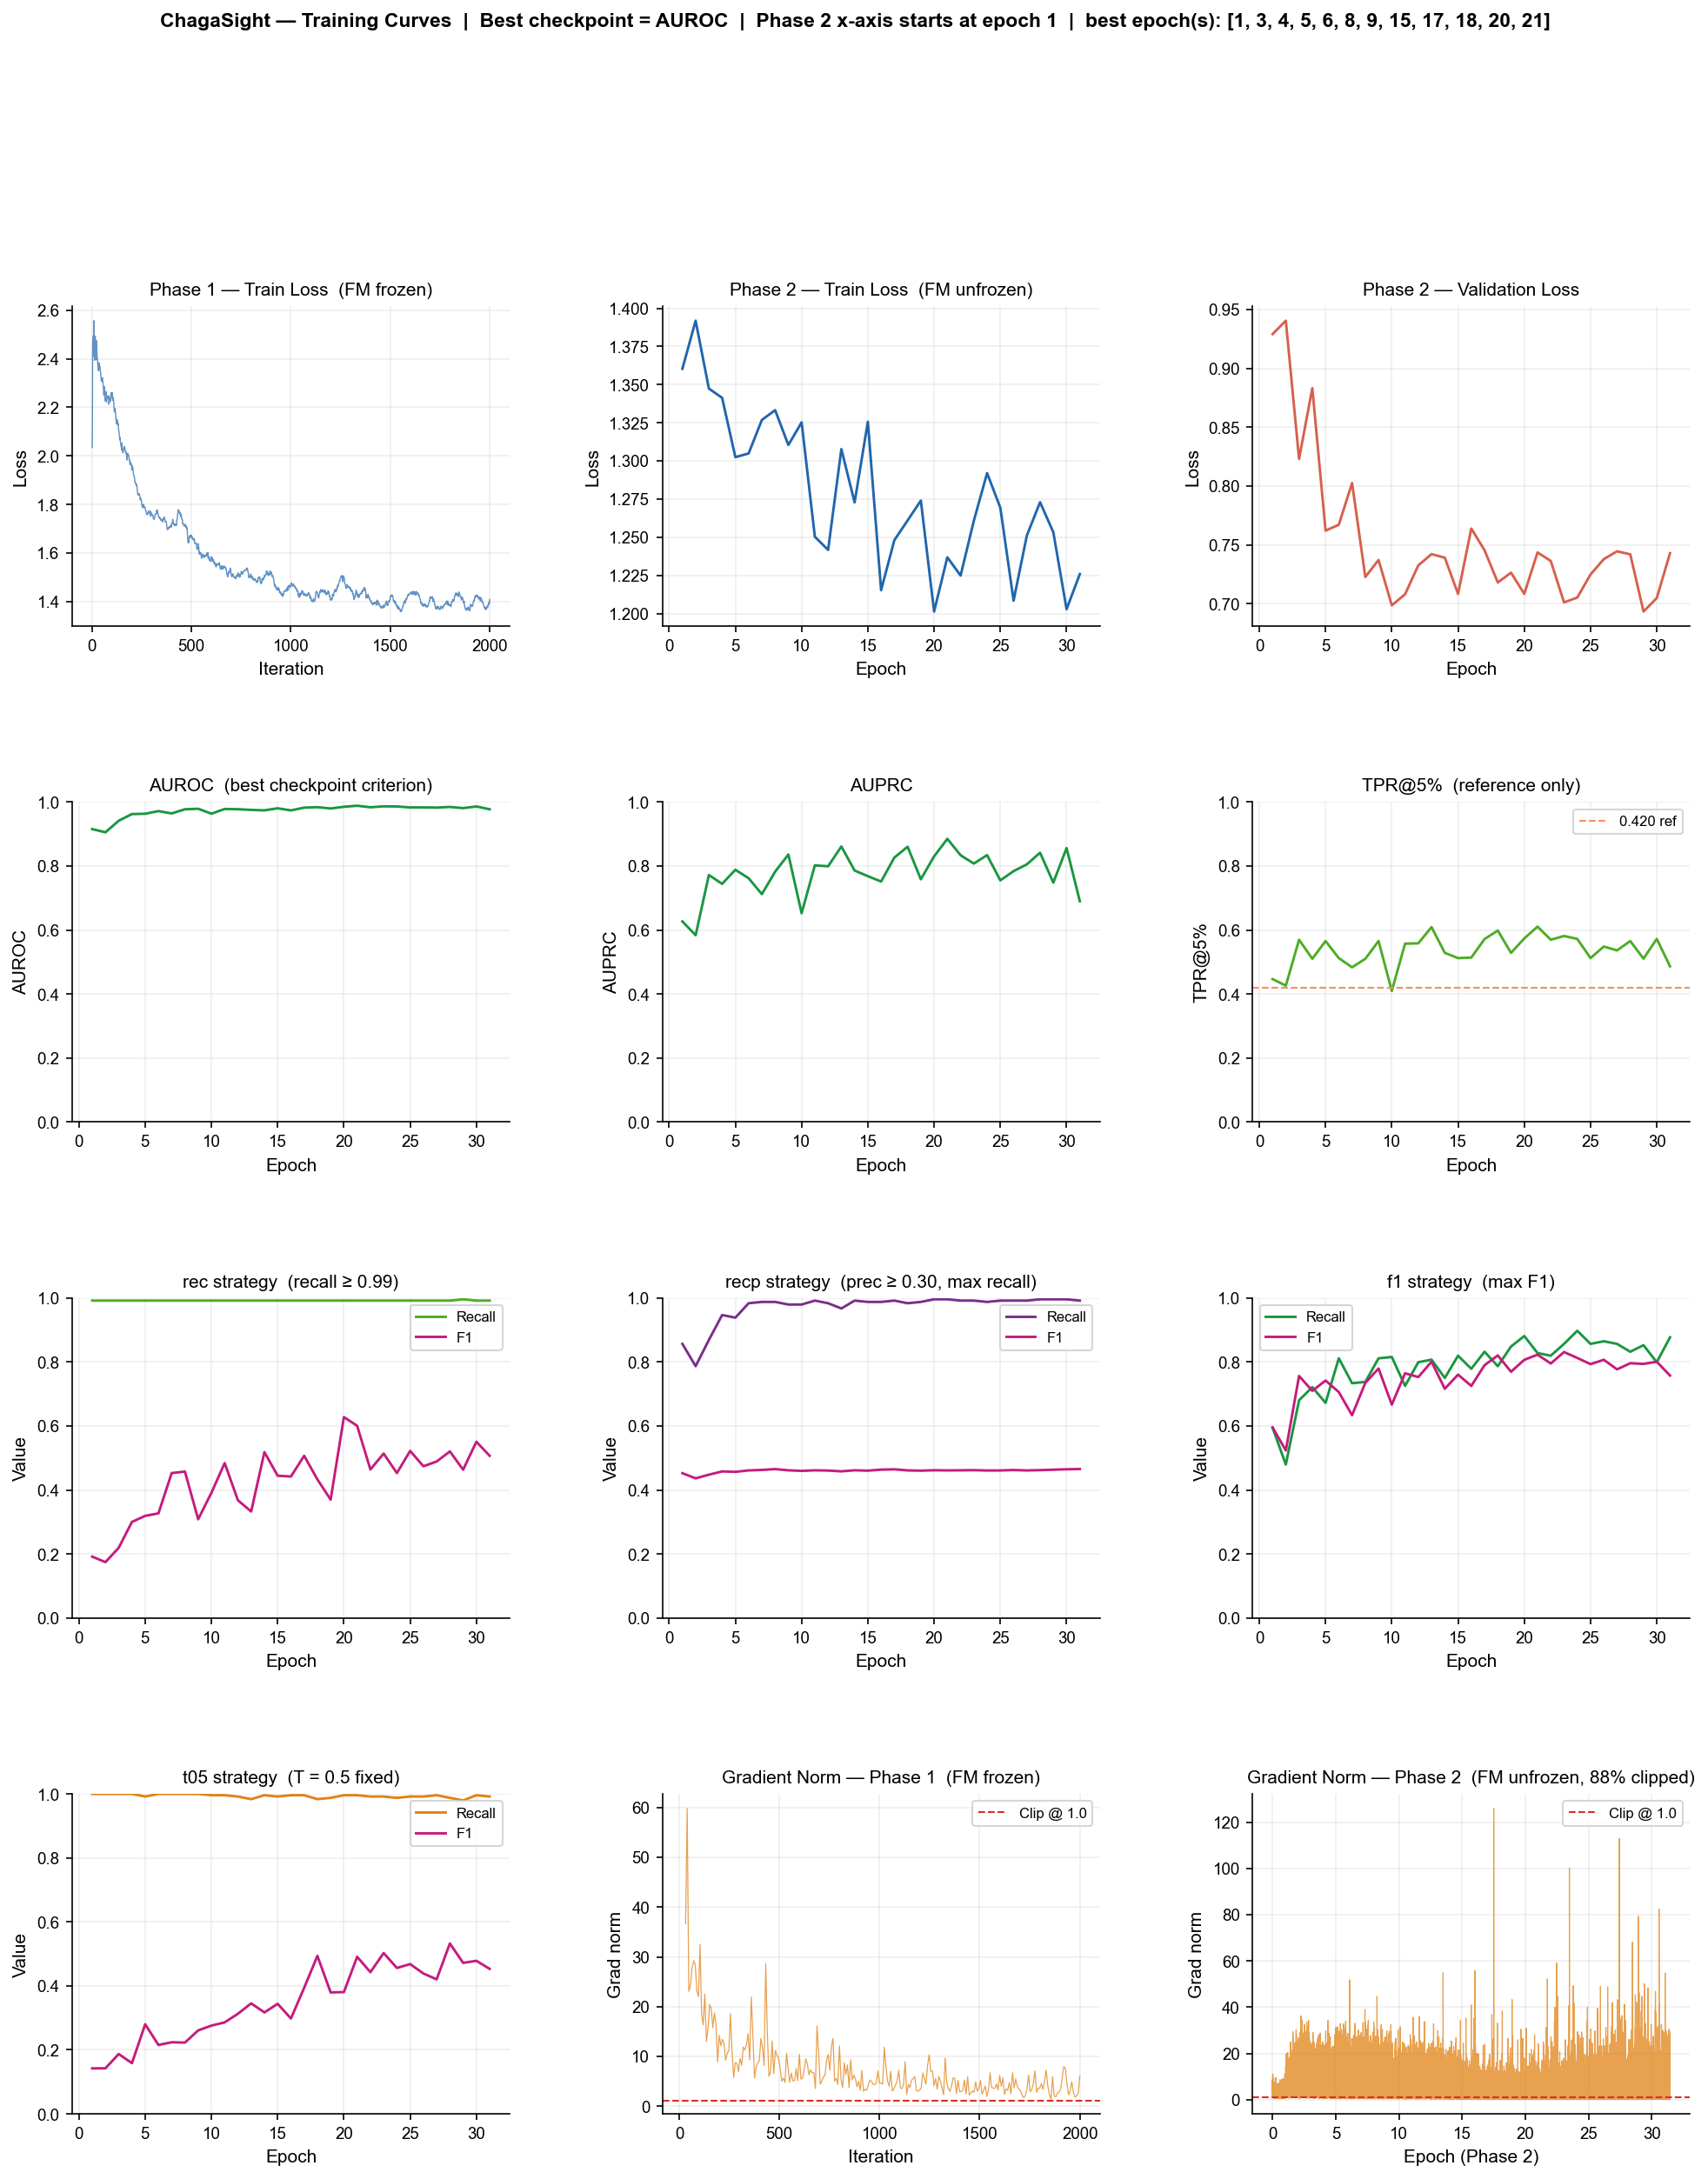

Saved: plots/final_split_training_curve.png  (300 DPI)
Saved: plots/metric_train_loss_phase1.png
Saved: plots/metric_train_loss_phase2.png
Saved: plots/metric_val_loss.png
Saved: plots/metric_auroc.png
Saved: plots/metric_auprc.png
Saved: plots/metric_tpr5pct.png
Saved: plots/metric_rec.png
Saved: plots/metric_recp.png
Saved: plots/metric_f1.png
Saved: plots/metric_t05.png
Saved: plots/metric_grad_norm.png

All training plots saved to: d:\IIT\L6\FYP\ChagaSight\checkpoints_new\full_p2_50epochs\plots
Best checkpoint epoch(s): [1, 3, 4, 5, 6, 8, 9, 15, 17, 18, 20, 21]


In [12]:
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
(PLOTS_DIR / 'final_v2').mkdir(parents=True, exist_ok=True)

matplotlib.rcParams.update({
    'font.size': 11, 'axes.titlesize': 10, 'axes.labelsize': 10,
    'xtick.labelsize': 9, 'ytick.labelsize': 9, 'legend.fontsize': 8,
    'figure.dpi': 150, 'axes.spines.top': False, 'axes.spines.right': False, 'font.family': 'sans-serif', 'font.sans-serif': ['Arial', 'Helvetica', 'DejaVu Sans'],
})

# ── Save val results CSV ───────────────────────────────────────────────────────
results_df = pd.DataFrame([metrics])
results_df['split'] = 'final'
results_df['phase2_epochs'] = PHASE2_MAX_EPOCHS
results_df['eff_batch'] = BATCH_SIZE * PHASE2_GRAD_ACCUM
results_df.to_csv(RESULTS_DIR / 'final_split_val_results.csv', index=False)
print('Saved: results/final_split_val_results.csv')

# ── Load epoch CSV — Phase 2 data source ──────────────────────────────────────
# The CSV epoch column starts at 1 (Phase 2 always starts from epoch 1).
_epoch_csv = RESULTS_DIR / 'final_split_epoch_results.csv'
if _epoch_csv.exists():
    ep_df = pd.read_csv(_epoch_csv)
    print(f'Loaded epoch CSV: {len(ep_df)} rows, epochs {ep_df["epoch"].min()}–{ep_df["epoch"].max()}')
else:
    ep_df = pd.DataFrame()
    print('WARNING: epoch CSV not found — Phase 2 plots will be empty.')

def _ep(col):
    """Return (epoch_list, value_list) from epoch CSV for a given column."""
    if ep_df.empty or col not in ep_df.columns:
        return [], []
    mask = ep_df[col].notna()
    return ep_df.loc[mask, 'epoch'].tolist(), ep_df.loc[mask, col].tolist()

def _best_epochs():
    """Epoch numbers where is_best == 1."""
    if ep_df.empty or 'is_best' not in ep_df.columns:
        return []
    return ep_df.loc[ep_df['is_best'] == 1, 'epoch'].tolist()

_best_ep = _best_epochs()
_STAR_KW = dict(marker='', color='red', s=0, zorder=10)

def _mark_best(ax, xs, ys, best_epochs=None):
    """Mark best-checkpoint epoch(s) with a gold star."""
    if not best_epochs or not xs:
        return
    ep_set = set(int(round(e)) for e in best_epochs)
    for x, y in zip(xs, ys):
        if int(round(x)) in ep_set:
            ax.scatter([x], [y], **_STAR_KW)

# ── Phase 1 data from trainer.history ─────────────────────────────────────────
history = trainer.history
spe     = STEPS_PER_EPOCH

# Phase 1 train loss: one value per iteration (batch step)
_p1_loss = history['train_loss'][:PHASE1_ITERATIONS]
p1_loss_x = list(range(1, len(_p1_loss) + 1))          # x = iteration number

# Gradient norms: stored per gradient-accum step
_p1_gn    = PHASE1_ITERATIONS // max(1, PHASE1_GRAD_ACCUM)
gn_p1     = history['grad_norm'][:_p1_gn]
gn_p2     = history['grad_norm'][_p1_gn:]
gn_p1_x   = [(i + 1) * max(1, PHASE1_GRAD_ACCUM) for i in range(len(gn_p1))]   # iteration
_p2_per_ep = max(1, spe // max(1, PHASE2_GRAD_ACCUM))
gn_p2_x   = [(i + 1) / _p2_per_ep for i in range(len(gn_p2))]                  # epoch

# ── Colors ────────────────────────────────────────────────────────────────────
C_TR   = '#2166ac'; C_VAL  = '#d6604d'; C_MET  = '#1a9641'
C_OR   = '#e08214'; C_F1   = '#c51b7d'
C_REC  = '#4dac26'; C_RECP = '#7b2d8b'

# ── Combined overview — 4 rows × 3 cols ───────────────────────────────────────
fig = plt.figure(figsize=(16, 18))
gs  = gridspec.GridSpec(4, 3, hspace=0.55, wspace=0.35)

# Row 0 — Loss (three separate panels)
# (0,0) Phase 1 train loss — x = iteration
ax = fig.add_subplot(gs[0, 0])
if _p1_loss:
    ax.plot(p1_loss_x, _p1_loss, lw=0.7, alpha=0.7, color=C_TR)
ax.set(xlabel='Iteration', ylabel='Loss', title='Phase 1 — Train Loss  (FM frozen)')
ax.grid(True, alpha=0.2)

# (0,1) Phase 2 train loss — x = epoch 1, 2, 3, ...
ax = fig.add_subplot(gs[0, 1])
ep_x, ep_tl = _ep('train_loss')
if ep_x:
    ax.plot(ep_x, ep_tl, 'o-', ms=3, lw=1.4, color=C_TR)
    _mark_best(ax, ep_x, ep_tl, _best_ep)
ax.set(xlabel='Epoch', ylabel='Loss', title='Phase 2 — Train Loss  (FM unfrozen)')
ax.grid(True, alpha=0.2)

# (0,2) Phase 2 val loss — x = epoch 1, 2, 3, ...
ax = fig.add_subplot(gs[0, 2])
ep_x, ep_vl = _ep('val_loss')
if ep_x:
    ax.plot(ep_x, ep_vl, 'o-', ms=3, lw=1.4, color=C_VAL)
    _mark_best(ax, ep_x, ep_vl, _best_ep)
ax.set(xlabel='Epoch', ylabel='Loss', title='Phase 2 — Validation Loss')
ax.grid(True, alpha=0.2)

# Row 1 — Threshold-free metrics
# (1,0) AUROC
ax = fig.add_subplot(gs[1, 0])
ep_x, ep_auroc = _ep('val_auroc')
if ep_x:
    ax.plot(ep_x, ep_auroc, 'o-', ms=3, lw=1.4, color=C_MET)
    _mark_best(ax, ep_x, ep_auroc, _best_ep)
ax.set(xlabel='Epoch', ylabel='AUROC', title='AUROC  (best checkpoint criterion)')
ax.set_ylim(0, 1); ax.grid(True, alpha=0.2)

# (1,1) AUPRC
ax = fig.add_subplot(gs[1, 1])
ep_x, ep_auprc = _ep('val_auprc')
if ep_x:
    ax.plot(ep_x, ep_auprc, 'o-', ms=3, lw=1.4, color=C_MET)
    _mark_best(ax, ep_x, ep_auprc, _best_ep)
ax.set(xlabel='Epoch', ylabel='AUPRC', title='AUPRC')
ax.set_ylim(0, 1); ax.grid(True, alpha=0.2)

# (1,2) TPR@5%
ax = fig.add_subplot(gs[1, 2])
ep_x, ep_tpr5 = _ep('val_tpr5')
if ep_x:
    ax.plot(ep_x, ep_tpr5, 'o-', ms=3, lw=1.4, color='#4dac26')
    ax.axhline(0.420, color='#fc8d59', ls='--', lw=1.0, label='0.420 ref')
    _mark_best(ax, ep_x, ep_tpr5, _best_ep)
    ax.legend()
ax.set(xlabel='Epoch', ylabel='TPR@5%', title='TPR@5%  (reference only)')
ax.set_ylim(0, 1); ax.grid(True, alpha=0.2)

# Row 2 — Named strategies: rec | recp | f1
# (2,0) rec strategy
ax = fig.add_subplot(gs[2, 0])
ep_x, ep_rec_rec = _ep('val_rec_rec')
_,    ep_rec_f1  = _ep('val_rec_f1')
if ep_x:
    ax.plot(ep_x, ep_rec_rec, 's-', ms=3, lw=1.4, color=C_REC,  label='Recall')
    ax.plot(ep_x, ep_rec_f1,  'D-', ms=3, lw=1.4, color=C_F1,   label='F1')
    _mark_best(ax, ep_x, ep_rec_rec, _best_ep)
ax.set(xlabel='Epoch', ylabel='Value', title='rec strategy  (recall ≥ 0.99)')
ax.set_ylim(0, 1); ax.legend(); ax.grid(True, alpha=0.2)

# (2,1) recp strategy
ax = fig.add_subplot(gs[2, 1])
ep_x, ep_recp_rec = _ep('val_recp_rec')
_,    ep_recp_f1  = _ep('val_recp_f1')
if ep_x:
    ax.plot(ep_x, ep_recp_rec, 's-', ms=3, lw=1.4, color=C_RECP, label='Recall')
    ax.plot(ep_x, ep_recp_f1,  'D-', ms=3, lw=1.4, color=C_F1,   label='F1')
    _mark_best(ax, ep_x, ep_recp_rec, _best_ep)
ax.set(xlabel='Epoch', ylabel='Value', title='recp strategy  (prec ≥ 0.30, max recall)')
ax.set_ylim(0, 1); ax.legend(); ax.grid(True, alpha=0.2)

# (2,2) f1 strategy
ax = fig.add_subplot(gs[2, 2])
ep_x, ep_f1_rec = _ep('val_f1_rec')
_,    ep_f1_f1  = _ep('val_f1_f1')
if ep_x:
    ax.plot(ep_x, ep_f1_rec, 's-', ms=3, lw=1.4, color=C_MET, label='Recall')
    ax.plot(ep_x, ep_f1_f1,  'D-', ms=3, lw=1.4, color=C_F1,  label='F1')
    _mark_best(ax, ep_x, ep_f1_rec, _best_ep)
ax.set(xlabel='Epoch', ylabel='Value', title='f1 strategy  (max F1)')
ax.set_ylim(0, 1); ax.legend(); ax.grid(True, alpha=0.2)

# Row 3 — t05 strategy | P1 grad norm | P2 grad norm
# (3,0) t05 strategy
ax = fig.add_subplot(gs[3, 0])
ep_x, ep_t05_rec = _ep('val_t05_rec')
_,    ep_t05_f1  = _ep('val_t05_f1')
if ep_x:
    ax.plot(ep_x, ep_t05_rec, 's-', ms=3, lw=1.4, color=C_OR,  label='Recall')
    ax.plot(ep_x, ep_t05_f1,  'D-', ms=3, lw=1.4, color=C_F1,  label='F1')
    _mark_best(ax, ep_x, ep_t05_rec, _best_ep)
ax.set(xlabel='Epoch', ylabel='Value', title='t05 strategy  (T = 0.5 fixed)')
ax.set_ylim(0, 1); ax.legend(); ax.grid(True, alpha=0.2)

# (3,1) Gradient norm — Phase 1
ax = fig.add_subplot(gs[3, 1])
if gn_p1:
    ax.plot(gn_p1_x, gn_p1, lw=0.6, alpha=0.75, color=C_OR)
    ax.axhline(MAX_GRAD_NORM, color='#d73027', ls='--', lw=1.0, label=f'Clip @ {MAX_GRAD_NORM}')
    ax.legend()
ax.set(xlabel='Iteration', ylabel='Grad norm', title='Gradient Norm — Phase 1  (FM frozen)')
ax.grid(True, alpha=0.2)

# (3,2) Gradient norm — Phase 2
ax = fig.add_subplot(gs[3, 2])
if gn_p2:
    clp2 = 100 * sum(1 for v in gn_p2 if v > MAX_GRAD_NORM) / max(1, len(gn_p2))
    ax.plot(gn_p2_x, gn_p2, lw=0.6, alpha=0.75, color=C_OR)
    ax.axhline(MAX_GRAD_NORM, color='#d73027', ls='--', lw=1.0, label=f'Clip @ {MAX_GRAD_NORM}')
    ax.legend()
    ax.set(xlabel='Epoch (Phase 2)', ylabel='Grad norm',
           title=f'Gradient Norm — Phase 2  (FM unfrozen, {clp2:.0f}% clipped)')
else:
    ax.text(0.5, 0.5, 'No Phase 2 grad data', ha='center', va='center',
            transform=ax.transAxes, fontsize=10, color='gray')
    ax.set(title='Gradient Norm — Phase 2  (FM unfrozen)')
ax.grid(True, alpha=0.2)

_best_str = f'best epoch(s): {_best_ep}' if _best_ep else 'no best checkpoint recorded'
fig.suptitle(
    f'ChagaSight — Training Curves  |  Best checkpoint = AUROC  |  '
    f'Phase 2 x-axis starts at epoch 1  |  {_best_str}',
    fontsize=11, fontweight='bold', y=1.005,
)
plt.savefig((PLOTS_DIR / 'final_v2') / 'final_split_training_curve.png', dpi=300, bbox_inches='tight')
plt.show()
print('Saved: plots/final_split_training_curve.png  (300 DPI)')

# ── Individual PNGs — helper ──────────────────────────────────────────────────
def _save_line(xs, ys, xlabel, ylabel, title, color, filename,
               best_ep=None, hlines=None, ylim=None, extra_series=None,
               marker='o', label=None):
    """Save a single-metric plot to PLOTS_DIR."""
    if not ys:
        return
    fig2, ax2 = plt.subplots(figsize=(7, 4))
    _lbl = label if extra_series else None   # only add label if legend needed
    ax2.plot(xs, ys, f'{marker}-', ms=4, lw=1.5, color=color, label=_lbl)
    if extra_series:
        for es in extra_series:
            ax2.plot(es['x'], es['y'], es.get('fmt', 'D-'),
                     ms=4, lw=1.5, color=es['color'], label=es['label'])
        ax2.legend(fontsize=8)
    if best_ep:
        _mark_best(ax2, xs, ys, best_ep)
    if hlines:
        for h in hlines:
            ax2.axhline(h['y'], color=h.get('c', 'gray'), ls=h.get('ls', '--'),
                        lw=1.0, label=h.get('label', ''))
        ax2.legend(fontsize=8)
    if ylim:
        ax2.set_ylim(*ylim)
    ax2.set(xlabel=xlabel, ylabel=ylabel, title=title)
    ax2.grid(True, alpha=0.25, lw=0.5)
    ax2.spines['top'].set_visible(False)
    ax2.spines['right'].set_visible(False)
    plt.tight_layout()
    plt.savefig((PLOTS_DIR / 'final_v2') / filename, dpi=300, bbox_inches='tight')
    plt.close()
    print(f'Saved: plots/{filename}')

# Phase 1 train loss (x = iteration)
_save_line(p1_loss_x, _p1_loss,
           'Iteration', 'Loss', 'Phase 1 — Train Loss  (FM frozen)',
           C_TR, 'metric_train_loss_phase1.png')

# Phase 2 train loss (x = epoch starting from 1)
ep_x, ep_tl = _ep('train_loss')
_save_line(ep_x, ep_tl,
           'Epoch', 'Loss', 'Phase 2 — Train Loss  (FM unfrozen)',
           C_TR, 'metric_train_loss_phase2.png', best_ep=_best_ep)

# Phase 2 val loss (x = epoch starting from 1)
ep_x, ep_vl = _ep('val_loss')
_save_line(ep_x, ep_vl,
           'Epoch', 'Loss', 'Phase 2 — Validation Loss',
           C_VAL, 'metric_val_loss.png', best_ep=_best_ep)

# AUROC (0–1, gold star at best)
ep_x, ep_auroc = _ep('val_auroc')
_save_line(ep_x, ep_auroc,
           'Epoch', 'AUROC', 'AUROC  (best checkpoint criterion)',
           C_MET, 'metric_auroc.png', best_ep=_best_ep, ylim=(0, 1))

# AUPRC (0–1)
ep_x, ep_auprc = _ep('val_auprc')
_save_line(ep_x, ep_auprc,
           'Epoch', 'AUPRC', 'AUPRC',
           C_MET, 'metric_auprc.png', best_ep=_best_ep, ylim=(0, 1))

# TPR@5% (0–1, reference line at 0.420)
ep_x, ep_tpr5 = _ep('val_tpr5')
_save_line(ep_x, ep_tpr5,
           'Epoch', 'TPR@5%', 'TPR@5%  (reference only)',
           '#4dac26', 'metric_tpr5pct.png', best_ep=_best_ep, ylim=(0, 1),
           hlines=[{'y': 0.420, 'c': '#fc8d59', 'label': '0.420 ref'}])

# rec strategy — Recall + F1
ep_x, ep_rec_rec = _ep('val_rec_rec')
_,    ep_rec_f1  = _ep('val_rec_f1')
_save_line(ep_x, ep_rec_rec,
           'Epoch', 'Value', 'rec strategy  (recall ≥ 0.99)',
           C_REC, 'metric_rec.png', best_ep=_best_ep, ylim=(0, 1),
           label='Recall', marker='s',
           extra_series=[{'x': ep_x, 'y': ep_rec_f1, 'color': C_F1,
                          'label': 'F1', 'fmt': 'D-'}])

# recp strategy — Recall + F1
ep_x, ep_recp_rec = _ep('val_recp_rec')
_,    ep_recp_f1  = _ep('val_recp_f1')
_save_line(ep_x, ep_recp_rec,
           'Epoch', 'Value', 'recp strategy  (prec ≥ 0.30, max recall)',
           C_RECP, 'metric_recp.png', best_ep=_best_ep, ylim=(0, 1),
           label='Recall', marker='s',
           extra_series=[{'x': ep_x, 'y': ep_recp_f1, 'color': C_F1,
                          'label': 'F1', 'fmt': 'D-'}])

# f1 strategy — Recall + F1
ep_x, ep_f1_rec = _ep('val_f1_rec')
_,    ep_f1_f1  = _ep('val_f1_f1')
_save_line(ep_x, ep_f1_rec,
           'Epoch', 'Value', 'f1 strategy  (max F1)',
           C_MET, 'metric_f1.png', best_ep=_best_ep, ylim=(0, 1),
           label='Recall', marker='s',
           extra_series=[{'x': ep_x, 'y': ep_f1_f1, 'color': C_F1,
                          'label': 'F1', 'fmt': 'D-'}])

# t05 strategy — Recall + F1
ep_x, ep_t05_rec = _ep('val_t05_rec')
_,    ep_t05_f1  = _ep('val_t05_f1')
_save_line(ep_x, ep_t05_rec,
           'Epoch', 'Value', 't05 strategy  (T = 0.5 fixed)',
           C_OR, 'metric_t05.png', best_ep=_best_ep, ylim=(0, 1),
           label='Recall', marker='s',
           extra_series=[{'x': ep_x, 'y': ep_t05_f1, 'color': C_F1,
                          'label': 'F1', 'fmt': 'D-'}])

# Gradient norm — Phase 1 and Phase 2 side by side
fig2, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4))
if gn_p1:
    ax1.plot(gn_p1_x, gn_p1, lw=0.6, alpha=0.8, color=C_OR)
    ax1.axhline(MAX_GRAD_NORM, color='#d73027', ls='--', lw=1.0, label=f'Clip @ {MAX_GRAD_NORM}')
    ax1.legend(fontsize=8)
ax1.set(xlabel='Iteration', ylabel='Grad norm', title='Gradient Norm — Phase 1  (FM frozen)')
ax1.grid(True, alpha=0.25)
ax1.spines['top'].set_visible(False); ax1.spines['right'].set_visible(False)
if gn_p2:
    clp2 = 100 * sum(1 for v in gn_p2 if v > MAX_GRAD_NORM) / max(1, len(gn_p2))
    ax2.plot(gn_p2_x, gn_p2, lw=0.6, alpha=0.8, color=C_OR)
    ax2.axhline(MAX_GRAD_NORM, color='#d73027', ls='--', lw=1.0, label=f'Clip @ {MAX_GRAD_NORM}')
    ax2.legend(fontsize=8)
    ax2.set(xlabel='Epoch (Phase 2)', ylabel='Grad norm',
            title=f'Gradient Norm — Phase 2  (FM unfrozen,  {clp2:.0f}% clipped)')
else:
    ax2.text(0.5, 0.5, 'No Phase 2 grad data\n(quick-test mode)', ha='center', va='center',
             transform=ax2.transAxes, fontsize=10, color='gray')
    ax2.set(title='Gradient Norm — Phase 2  (FM unfrozen)')
ax2.grid(True, alpha=0.25)
ax2.spines['top'].set_visible(False); ax2.spines['right'].set_visible(False)
plt.tight_layout()
plt.savefig((PLOTS_DIR / 'final_v2') / 'metric_grad_norm.png', dpi=300, bbox_inches='tight')
plt.close()
print('Saved: plots/metric_grad_norm.png')

print(f'\nAll training plots saved to: {PLOTS_DIR}')
print(f'Best checkpoint epoch(s): {_best_ep}')

## Cell 9 — Final Evaluation on Held-Out Test Set

**Run this cell only once, after training is complete.**  
The Youden-optimal threshold is taken from the best validation checkpoint.  
It is applied unchanged to the test set (no re-fitting on test data).

Loaded best checkpoint
  Val AUROC:  0.988532658898423
  Epoch:      21

  HELD-OUT TEST SET RESULTS
  AUROC:  0.9870   (PRIMARY — best checkpoint criterion)
  AUPRC:  0.8827
  TPR@5%: 0.5976   (reference)
  N=3198  Positives=246

  rec strategy (max recall >= 0.99):
    T=0.3860  Recall=0.9919  Precision=0.2785  F1=0.4349  F2=0.6559  Spec=0.7859  NPV=0.9991
    TP=244  FP=632  FN=2  TN=2320

  recp strategy (max recall, precision >= 0.30):
    T=0.4953  Recall=0.9878  Precision=0.3249  F1=0.4889  F2=0.7015  Spec=0.8289  NPV=0.9988
    TP=243  FP=505  FN=3  TN=2447

  f1 strategy (max F1):
    T=0.7262  Recall=0.8049  Precision=0.8462  F1=0.8250  F2=0.8128  Spec=0.9878  NPV=0.9838
    TP=198  FP=36  FN=48  TN=2916

  t05 strategy (fixed T=0.5):
    T=0.5000  Recall=0.9837  Precision=0.3275  F1=0.4914  F2=0.7023  Spec=0.8316  NPV=0.9984
    TP=242  FP=497  FN=4  TN=2455

  Sensitivity analysis — operating points:
      Target  Threshold   Recall  Precision      F1     TP     FP     FN  

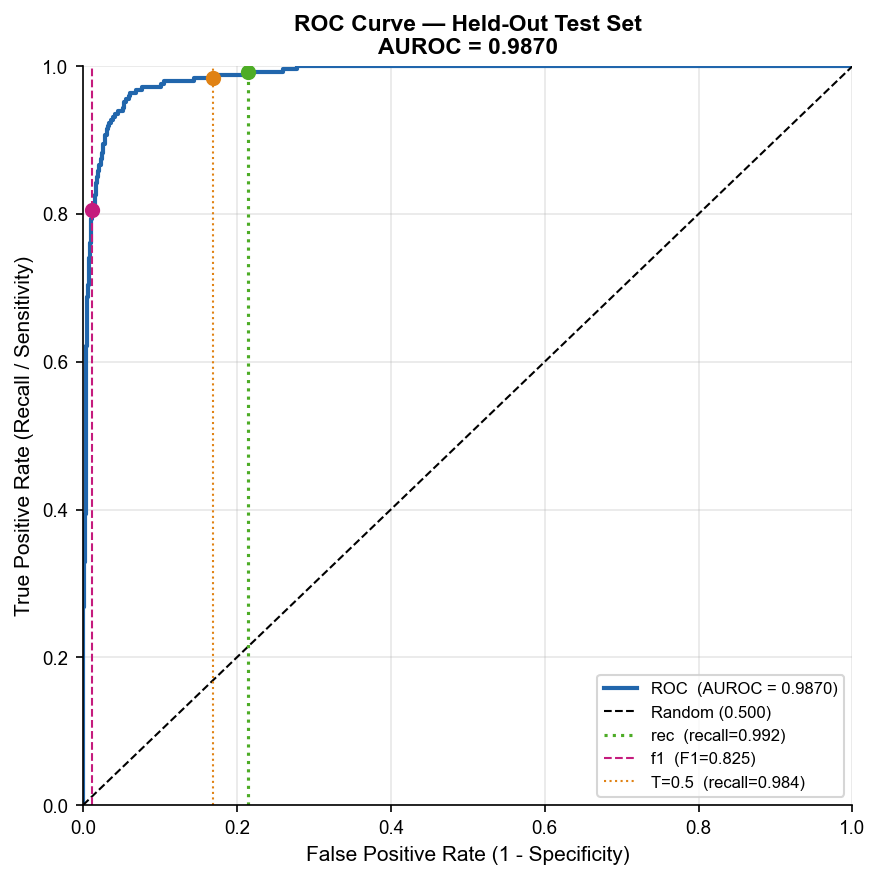

Saved: plots/final_split_roc_curve.png  (300 DPI)


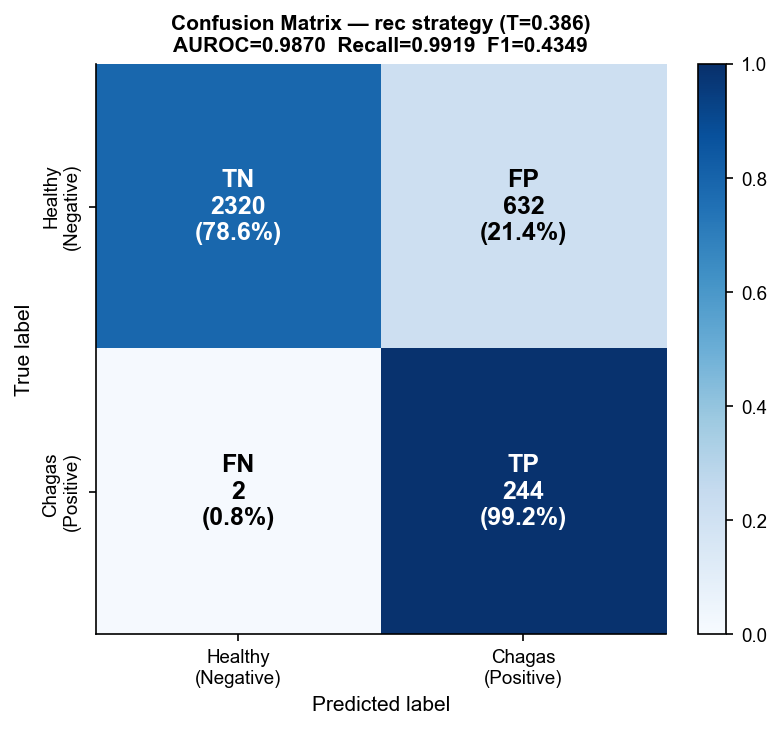

Saved: plots/final_split_confusion_matrix.png  (300 DPI)


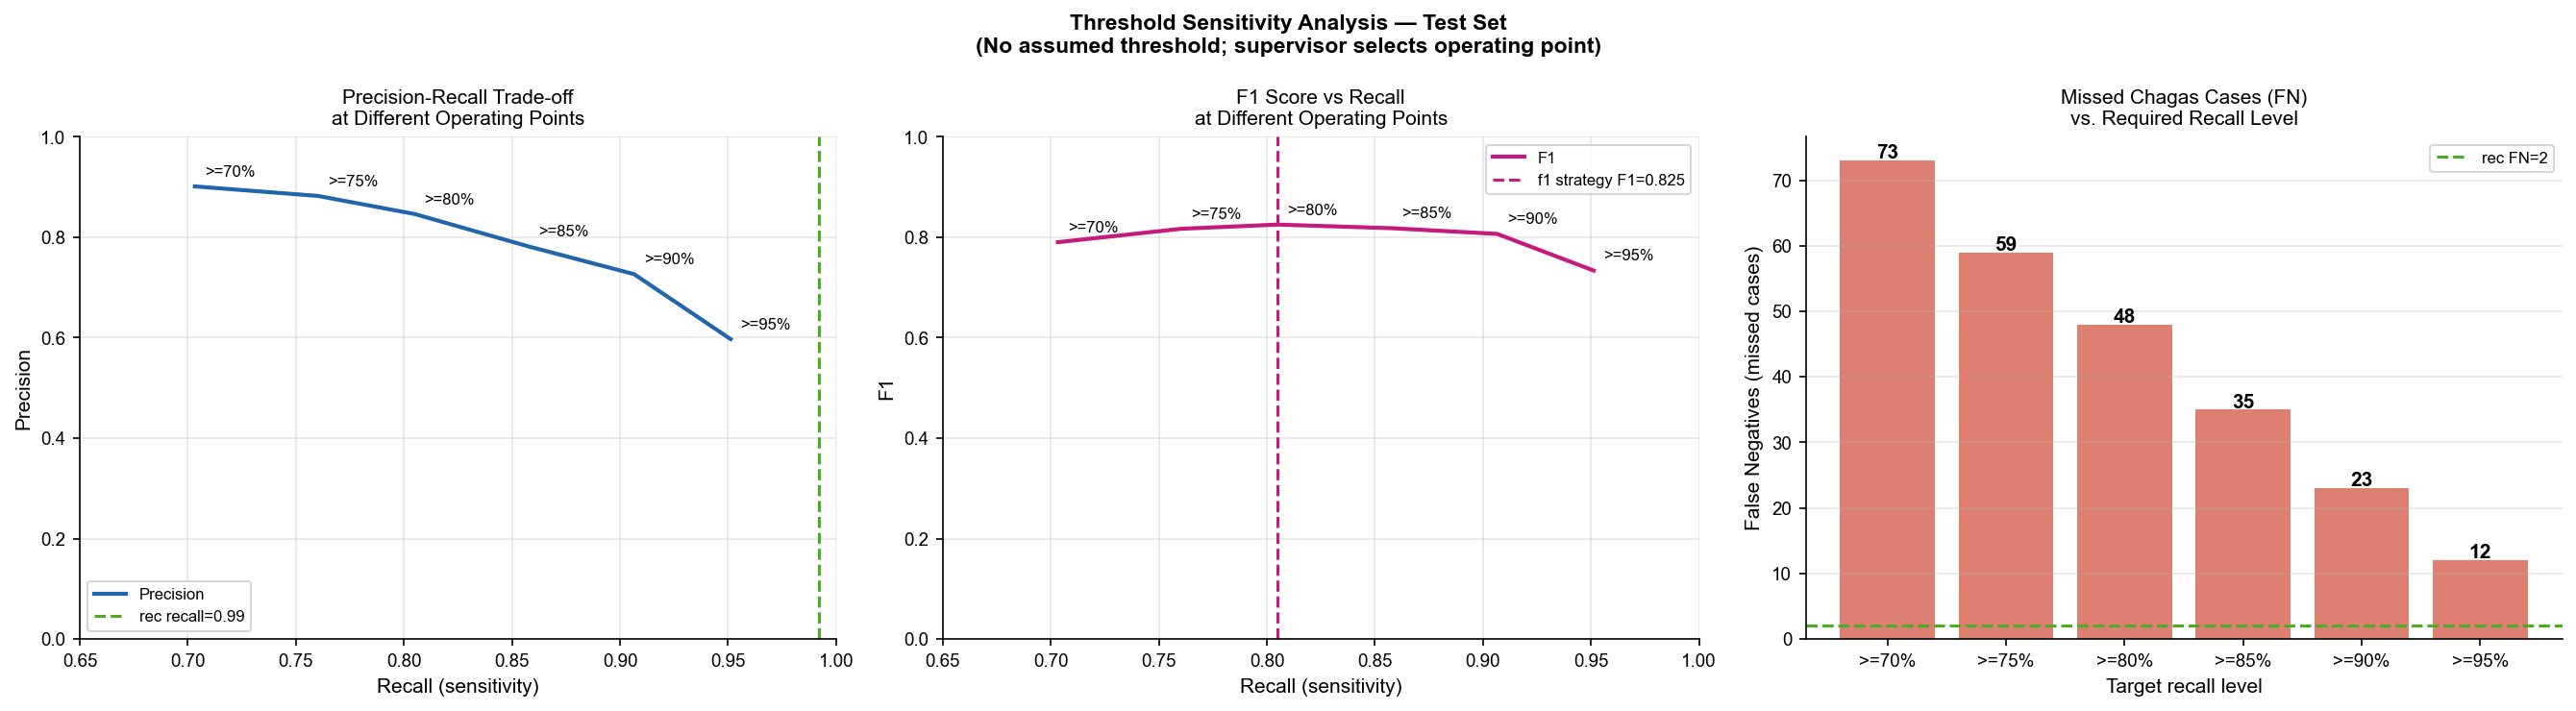

Saved: plots/final_split_sensitivity_analysis.png  (300 DPI)
Saved: results/final_split_test_results.csv
Saved: results/final_split_sensitivity_analysis.csv
Saved: results/final_split_test_predictions.csv
TensorBoard updated.
Saved: results/metrics_best.json


In [13]:
import torch, math, json as _json
import matplotlib.pyplot as plt
import numpy as np
from src.training.metrics import compute_metrics, threshold_min_recall
from sklearn.metrics import precision_score, recall_score, accuracy_score, roc_curve

best_ckpt = RUN_DIR / 'foldfinal_best.pt'
assert best_ckpt.exists(), f'Best checkpoint not found: {best_ckpt}'

ckpt = torch.load(best_ckpt, map_location=device, weights_only=False)
model.load_state_dict(ckpt['model_state_dict'])
print(f'Loaded best checkpoint')
print(f'  Val AUROC:  {ckpt.get("val_score", "?")}')
print(f'  Epoch:      {ckpt.get("current_epoch", ckpt.get("iteration", "?"))}')
del ckpt

# ── Run model on test set ─────────────────────────────────────────────────────
model.eval()
all_logits, all_labels, all_datasets = [], [], []

with torch.no_grad():
    for batch in test_loader:
        out = model(batch['image'].to(device),  batch['signal'].to(device),
                    batch['age'].to(device),    batch['sex'].to(device))
        all_logits.append(out['logits'].cpu())
        all_labels.append(batch['hard_label'].cpu())
        all_datasets.extend(batch['dataset'])

scores    = torch.sigmoid(torch.cat(all_logits).float()).numpy()
labels_np = torch.cat(all_labels).float().numpy().astype(int)

# ── All metrics — 4 strategies computed on test set ──────────────────────────
test_metrics = compute_metrics(labels_np, scores, num_permutations=4000,
                               threshold_strategy=THRESHOLD_STRATEGY,
                               threshold_kwargs=THRESHOLD_KWARGS,
                               rec_min_recall=0.99, recp_min_precision=0.30)

# ── Sensitivity analysis ──────────────────────────────────────────────────────
recall_targets = [0.70, 0.75, 0.80, 0.85, 0.90, 0.95]
sens_rows = []
for target_recall in recall_targets:
    thr = threshold_min_recall(labels_np, scores, min_recall=target_recall)
    preds = (scores >= thr).astype(int)
    prec = float(precision_score(labels_np, preds, zero_division=0))
    rec  = float(recall_score(labels_np, preds, zero_division=0))
    f1_v = 2 * prec * rec / (prec + rec) if (prec + rec) > 0 else 0.0
    acc  = float(accuracy_score(labels_np, preds))
    tp_s = int(np.sum((preds == 1) & (labels_np == 1)))
    fp_s = int(np.sum((preds == 1) & (labels_np == 0)))
    fn_s = int(np.sum((preds == 0) & (labels_np == 1)))
    tn_s = int(np.sum((preds == 0) & (labels_np == 0)))
    sens_rows.append({
        'Target recall': f'>={target_recall:.0%}',
        'Threshold':     f'{thr:.3f}',
        'Actual recall': f'{rec:.3f}',
        'Precision':     f'{prec:.3f}',
        'F1':            f'{f1_v:.3f}',
        'Accuracy':      f'{acc:.3f}',
        'TP': tp_s, 'FP': fp_s, 'FN': fn_s, 'TN': tn_s,
        '_thr': thr, '_rec': rec, '_prec': prec, '_f1': f1_v,
    })

# ── Print results ─────────────────────────────────────────────────────────────
print('\n' + '='*70)
print('  HELD-OUT TEST SET RESULTS')
print('='*70)
print(f'  AUROC:  {test_metrics["auroc"]:.4f}   (PRIMARY — best checkpoint criterion)')
print(f'  AUPRC:  {test_metrics.get("auprc",0):.4f}')
print(f'  TPR@5%: {test_metrics["tpr_5pct"]:.4f}   (reference)')
print(f'  N={len(labels_np)}  Positives={int(labels_np.sum())}')
print()
print(f'  rec strategy (max recall >= 0.99):')
print(f'    T={test_metrics["rec_thr"]:.4f}  Recall={test_metrics["rec_rec"]:.4f}  '
      f'Precision={test_metrics["rec_prec"]:.4f}  F1={test_metrics["rec_f1"]:.4f}  '
      f'F2={test_metrics["rec_f2"]:.4f}  Spec={test_metrics["rec_spec"]:.4f}  NPV={test_metrics["rec_npv"]:.4f}')
print(f'    TP={test_metrics["rec_tp"]}  FP={test_metrics["rec_fp"]}  '
      f'FN={test_metrics["rec_fn"]}  TN={test_metrics["rec_tn"]}')
print()
print(f'  recp strategy (max recall, precision >= 0.30):')
print(f'    T={test_metrics["recp_thr"]:.4f}  Recall={test_metrics["recp_rec"]:.4f}  '
      f'Precision={test_metrics["recp_prec"]:.4f}  F1={test_metrics["recp_f1"]:.4f}  '
      f'F2={test_metrics["recp_f2"]:.4f}  Spec={test_metrics["recp_spec"]:.4f}  NPV={test_metrics["recp_npv"]:.4f}')
print(f'    TP={test_metrics["recp_tp"]}  FP={test_metrics["recp_fp"]}  '
      f'FN={test_metrics["recp_fn"]}  TN={test_metrics["recp_tn"]}')
print()
print(f'  f1 strategy (max F1):')
print(f'    T={test_metrics["f1_thr"]:.4f}  Recall={test_metrics["f1_rec"]:.4f}  '
      f'Precision={test_metrics["f1_prec"]:.4f}  F1={test_metrics["f1_f1"]:.4f}  '
      f'F2={test_metrics["f1_f2"]:.4f}  Spec={test_metrics["f1_spec"]:.4f}  NPV={test_metrics["f1_npv"]:.4f}')
print(f'    TP={test_metrics["f1_tp"]}  FP={test_metrics["f1_fp"]}  '
      f'FN={test_metrics["f1_fn"]}  TN={test_metrics["f1_tn"]}')
print()
print(f'  t05 strategy (fixed T=0.5):')
print(f'    T=0.5000  Recall={test_metrics["t05_rec"]:.4f}  '
      f'Precision={test_metrics["t05_prec"]:.4f}  F1={test_metrics["t05_f1"]:.4f}  '
      f'F2={test_metrics["t05_f2"]:.4f}  Spec={test_metrics["t05_spec"]:.4f}  NPV={test_metrics["t05_npv"]:.4f}')
print(f'    TP={test_metrics["t05_tp"]}  FP={test_metrics["t05_fp"]}  '
      f'FN={test_metrics["t05_fn"]}  TN={test_metrics["t05_tn"]}')
print()
print('  Sensitivity analysis — operating points:')
print(f'  {"Target":>10}  {"Threshold":>9}  {"Recall":>7}  {"Precision":>9}  '
      f'{"F1":>6}  {"TP":>5}  {"FP":>5}  {"FN":>5}  {"TN":>6}')
print('  ' + '-'*71)
for r in sens_rows:
    print(f'  {r["Target recall"]:>10}  {r["Threshold"]:>9}  {r["Actual recall"]:>7}  '
          f'{r["Precision"]:>9}  {r["F1"]:>6}  {r["TP"]:>5}  {r["FP"]:>5}  '
          f'{r["FN"]:>5}  {r["TN"]:>6}')
print()
print('  FN = missed Chagas cases. FP = false alarms on healthy patients.')
print('='*70)

# ── Plot 1: ROC Curve ─────────────────────────────────────────────────────────
fpr_roc, tpr_roc, _ = roc_curve(labels_np, scores)
fig, ax = plt.subplots(figsize=(6, 6))
ax.plot(fpr_roc, tpr_roc, lw=2, color='#2166ac',
        label=f'ROC  (AUROC = {test_metrics["auroc"]:.4f})')
ax.plot([0, 1], [0, 1], 'k--', lw=1, label='Random (0.500)')
fpr_rec = 1.0 - test_metrics['rec_spec']
ax.scatter([fpr_rec], [test_metrics['rec_rec']], color='#4dac26', s=40, zorder=6, marker='o')
ax.axvline(fpr_rec, color='#4dac26', ls=':', lw=1.5,
           label=f'rec  (recall={test_metrics["rec_rec"]:.3f})')
fpr_f1 = 1.0 - test_metrics['f1_spec']
ax.scatter([fpr_f1], [test_metrics['f1_rec']], color='#c51b7d', s=40, zorder=5, marker='o')
ax.axvline(fpr_f1, color='#c51b7d', ls='--', lw=1.0,
           label=f'f1  (F1={test_metrics["f1_f1"]:.3f})')
fpr_t05 = 1.0 - test_metrics['t05_spec']
ax.scatter([fpr_t05], [test_metrics['t05_rec']], color='#e08214', s=40, zorder=5, marker='o')
ax.axvline(fpr_t05, color='#e08214', ls=':', lw=1.0,
           label=f'T=0.5  (recall={test_metrics["t05_rec"]:.3f})')
ax.set_xlabel('False Positive Rate (1 - Specificity)')
ax.set_ylabel('True Positive Rate (Recall / Sensitivity)')
ax.set_title(f'ROC Curve — Held-Out Test Set\nAUROC = {test_metrics["auroc"]:.4f}',
             fontsize=11, fontweight='bold')
ax.legend(fontsize=8); ax.grid(True, alpha=0.3)
ax.set_xlim(0, 1); ax.set_ylim(0, 1)
plt.tight_layout()
plt.savefig((PLOTS_DIR / 'final_v2') / 'final_split_roc_curve.png', dpi=300, bbox_inches='tight')
plt.show()
print('Saved: plots/final_split_roc_curve.png  (300 DPI)')

# ── Plot 2: Confusion Matrix (rec strategy — highest recall) ──────────────────
tp_r, fp_r, fn_r, tn_r = (test_metrics['rec_tp'], test_metrics['rec_fp'],
                            test_metrics['rec_fn'], test_metrics['rec_tn'])
cm_r = np.array([[tn_r, fp_r], [fn_r, tp_r]])
cm_n = cm_r.astype(float) / cm_r.sum(axis=1, keepdims=True)
fig, ax = plt.subplots(figsize=(6, 5))
im = ax.imshow(cm_n, cmap='Blues', vmin=0, vmax=1)
plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
ax.set_xticks([0, 1]); ax.set_xticklabels(['Healthy\n(Negative)', 'Chagas\n(Positive)'])
ax.set_yticks([0, 1]); ax.set_yticklabels(['Healthy\n(Negative)', 'Chagas\n(Positive)'],
                                            rotation=90, va='center')
ax.set_xlabel('Predicted label'); ax.set_ylabel('True label')
ax.set_title(f'Confusion Matrix — rec strategy (T={test_metrics["rec_thr"]:.3f})\n'
             f'AUROC={test_metrics["auroc"]:.4f}  Recall={test_metrics["rec_rec"]:.4f}  '
             f'F1={test_metrics["rec_f1"]:.4f}',
             fontsize=10, fontweight='bold')
for row, col, count, lbl, nv in [
    (0, 0, tn_r, 'TN', cm_n[0,0]), (0, 1, fp_r, 'FP', cm_n[0,1]),
    (1, 0, fn_r, 'FN', cm_n[1,0]), (1, 1, tp_r, 'TP', cm_n[1,1])
]:
    color = 'white' if nv > 0.5 else 'black'
    ax.text(col, row, f'{lbl}\n{count}\n({nv:.1%})',
            ha='center', va='center', fontsize=12, fontweight='bold', color=color)
plt.tight_layout()
plt.savefig((PLOTS_DIR / 'final_v2') / 'final_split_confusion_matrix.png', dpi=300, bbox_inches='tight')
plt.show()
print('Saved: plots/final_split_confusion_matrix.png  (300 DPI)')

# ── Plot 3: Sensitivity Analysis ──────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
recalls    = [float(r['_rec'])  for r in sens_rows]
precisions = [float(r['_prec']) for r in sens_rows]
f1s        = [float(r['_f1'])   for r in sens_rows]
fns        = [r['FN']           for r in sens_rows]

ax = axes[0]
ax.plot(recalls, precisions, 'o-', lw=2, ms=7, color='#2166ac', label='Precision')
ax.axvline(test_metrics['rec_rec'], color='#4dac26', ls='--', lw=1.5,
           label=f'rec recall={test_metrics["rec_rec"]:.2f}')
ax.set_xlabel('Recall (sensitivity)'); ax.set_ylabel('Precision')
ax.set_title('Precision-Recall Trade-off\nat Different Operating Points')
ax.set_xlim(0.65, 1.0); ax.set_ylim(0, 1); ax.legend(); ax.grid(True, alpha=0.3)
for i, r in enumerate(sens_rows):
    ax.annotate(r['Target recall'], (float(r['_rec']), float(r['_prec'])),
                textcoords='offset points', xytext=(5, 5), fontsize=8)

ax = axes[1]
ax.plot(recalls, f1s, 'D-', lw=2, ms=7, color='#c51b7d', label='F1')
ax.axvline(test_metrics['f1_rec'], color='#c51b7d', ls='--', lw=1.5,
           label=f'f1 strategy F1={test_metrics["f1_f1"]:.3f}')
ax.set_xlabel('Recall (sensitivity)'); ax.set_ylabel('F1')
ax.set_title('F1 Score vs Recall\nat Different Operating Points')
ax.set_xlim(0.65, 1.0); ax.set_ylim(0, 1); ax.legend(); ax.grid(True, alpha=0.3)
for i, r in enumerate(sens_rows):
    ax.annotate(r['Target recall'], (float(r['_rec']), float(r['_f1'])),
                textcoords='offset points', xytext=(5, 5), fontsize=8)

ax = axes[2]
ax.bar(range(len(recall_targets)), fns, color='#d6604d', alpha=0.8)
ax.axhline(test_metrics['rec_fn'], color='#4dac26', ls='--', lw=1.5,
           label=f'rec FN={test_metrics["rec_fn"]}')
ax.set_xticks(range(len(recall_targets)))
ax.set_xticklabels([r['Target recall'] for r in sens_rows])
ax.set_xlabel('Target recall level'); ax.set_ylabel('False Negatives (missed cases)')
ax.set_title('Missed Chagas Cases (FN)\nvs. Required Recall Level')
ax.legend(); ax.grid(True, alpha=0.3, axis='y')
for i, v in enumerate(fns):
    ax.text(i, v + 0.3, str(v), ha='center', fontsize=10, fontweight='bold')
fig.suptitle('Threshold Sensitivity Analysis — Test Set\n'
             '(No assumed threshold; supervisor selects operating point)',
             fontsize=11, fontweight='bold')
plt.tight_layout()
plt.savefig((PLOTS_DIR / 'final_v2') / 'final_split_sensitivity_analysis.png', dpi=300, bbox_inches='tight')
plt.show()
print('Saved: plots/final_split_sensitivity_analysis.png  (300 DPI)')

# ── Save CSVs ─────────────────────────────────────────────────────────────────
test_df = pd.DataFrame([test_metrics])
test_df['split'] = 'test'
test_df.to_csv(RESULTS_DIR / 'final_split_test_results.csv', index=False)

pd.DataFrame(sens_rows).drop(columns=['_thr','_rec','_prec','_f1']).to_csv(
    RESULTS_DIR / 'final_split_sensitivity_analysis.csv', index=False)

preds_rec = (scores >= test_metrics['rec_thr']).astype(int)
preds_f1  = (scores >= test_metrics['f1_thr']).astype(int)
preds_t05 = (scores >= 0.5).astype(int)
pd.DataFrame({'dataset': all_datasets, 'label': labels_np, 'score': scores,
              'pred_rec': preds_rec, 'pred_f1': preds_f1,
              'pred_t05': preds_t05}).to_csv(
    RESULTS_DIR / 'final_split_test_predictions.csv', index=False)

print('Saved: results/final_split_test_results.csv')
print('Saved: results/final_split_sensitivity_analysis.csv')
print('Saved: results/final_split_test_predictions.csv')

# ── TensorBoard ───────────────────────────────────────────────────────────────
for tag, val in [
    ('Test/AUROC',      test_metrics['auroc']),
    ('Test/AUPRC',      test_metrics.get('auprc', 0)),
    ('Test/TPR5pct',    test_metrics['tpr_5pct']),
    ('Test/Rec_Recall', test_metrics['rec_rec']),
    ('Test/Rec_Prec',   test_metrics['rec_prec']),
    ('Test/Rec_F1',     test_metrics['rec_f1']),
    ('Test/F1_Recall',  test_metrics['f1_rec']),
    ('Test/F1_F1',      test_metrics['f1_f1']),
    ('Test/T05_Recall', test_metrics['t05_rec']),
    ('Test/T05_F1',     test_metrics['t05_f1']),
]:
    tb_writer.add_scalar(tag, val, global_step=0)
tb_writer.flush()
print('TensorBoard updated.')

# ── Save metrics_best.json (val + test combined, Dewmika format) ──────────────
_val_best_path = RESULTS_DIR / 'val_best_metrics.json'
if _val_best_path.exists():
    with open(_val_best_path) as _f:
        _metrics_best = _json.load(_f)
else:
    _metrics_best = {}
_metrics_best.update({
    'test_auroc': test_metrics['auroc'],
    'test_auprc': test_metrics.get('auprc', 0.0),
    'test_tpr5':  test_metrics['tpr_5pct'],
})
for s in ('rec', 'recp', 'f1', 't05'):
    for k in ('thr', 'tp', 'fp', 'tn', 'fn', 'acc', 'prec', 'rec', 'spec', 'npv', 'f1', 'f2'):
        default = 0 if k in ('tp', 'fp', 'tn', 'fn') else float('nan')
        _metrics_best[f'test_{s}_{k}'] = test_metrics.get(f'{s}_{k}', default)
with open(RESULTS_DIR / 'metrics_best.json', 'w') as _f:
    _json.dump(_metrics_best, _f, indent=2)
print('Saved: results/metrics_best.json')

## Cell 10 — Checkpoint Verification

In [11]:
print(f'Run folder: {RUN_DIR}')
print()
print('Checkpoint files:')
for p in sorted(RUN_DIR.glob('foldfinal*.pt')):
    print(f'  {p.name}  ({p.stat().st_size/1e6:.0f} MB)')

print('\nResult CSVs (results/):')
for fname in ['final_split_val_results.csv',
              'final_split_epoch_results.csv',
              'final_split_test_results.csv',
              'final_split_sensitivity_analysis.csv',
              'final_split_test_predictions.csv']:
    fpath = RESULTS_DIR / fname
    if fpath.exists():
        df_tmp = pd.read_csv(fpath)
        cols = [c for c in ['epoch', 'lr', 'val_tpr5', 'val_auroc', 'val_auprc',
                             'val_rec_thr', 'val_rec_rec', 'val_rec_f1',
                             'val_f1_thr', 'val_f1_rec', 'val_f1_f1',
                             'val_recp_thr', 'val_recp_rec', 'val_recp_f1',
                             'val_t05_thr', 'val_t05_rec', 'val_t05_f1', 'is_best']
                if c in df_tmp.columns]
        print(f'\n  {fname}  ({len(df_tmp)} rows):')
        print(df_tmp[cols].tail(5).to_string(index=False))
    else:
        print(f'\n  {fname}:  (not yet created)')

print('\nResult JSONs (results/):')
for fname in ['val_best_metrics.json', 'metrics_best.json']:
    fpath = RESULTS_DIR / fname
    if fpath.exists():
        import json as _json
        with open(fpath) as _f:
            _d = _json.load(_f)
        print(f'\n  {fname}  ({len(_d)} keys):')
        for k, v in list(_d.items())[:8]:
            print(f'    {k}: {v}')
        if len(_d) > 8:
            print(f'    ... ({len(_d)-8} more keys)')
    else:
        print(f'\n  {fname}:  (not yet created)')

print('\nPlot files (plots/):')
for p in sorted(PLOTS_DIR.glob('*.png')):
    print(f'  {p.name}  ({p.stat().st_size/1e3:.0f} KB)')

print(f'\nTensorBoard: tensorboard --logdir "{TB_LOG_DIR}"')

tb_writer.close()
print('TensorBoard writer closed.')

Run folder: d:\IIT\L6\FYP\ChagaSight\checkpoints_new\full_p2_50epochs

Checkpoint files:
  foldfinal_best.pt  (2160 MB)
  foldfinal_latest.pt  (2178 MB)

Result CSVs (results/):

  final_split_val_results.csv  (1 rows):
Empty DataFrame
Columns: []
Index: [0]

  final_split_epoch_results.csv  (31 rows):
 epoch      lr  val_tpr5  val_auroc  val_auprc  val_rec_thr  val_rec_rec  val_rec_f1  val_f1_thr  val_f1_rec  val_f1_f1  val_recp_thr  val_recp_rec  val_recp_f1  val_t05_thr  val_t05_rec  val_t05_f1  is_best
    27 0.00002  0.536439   0.982734   0.805293     0.628906     0.991803    0.488889    0.726074    0.856557   0.776952      0.588379      0.991803     0.460952          0.5     0.995902    0.420415        0
    28 0.00002  0.565574   0.984755   0.841653     0.469238     0.991803    0.520430    0.717773    0.831967   0.796078      0.343994      0.995902     0.461977          0.5     0.987705    0.532597        0
    29 0.00002  0.510586   0.981050   0.748243     0.466064     0.995902